# KNAPSACK PROBLEM EXERCISE

Given items with weights and values, and a weight capacity, maximize value without exceeding capacity.
Items: (weight, value) = (2,3), (3,4), (4,5), (5,8). Capacity: 8

# CLASSICAL (BRUTEFORCE) SOLUTION

In [1]:
import numpy as np

# Helper function to find the biggest value in a list
def find_max(list):
    max = 0
    bitstring = ""
    for value, variables in list:
        if max < value:
            max = value
            bitstring = variables
    return [max, bitstring]

# Helper function to build all the possible binary strings with n bits
def build_profile(number):
    list = []
    for case in range(2**number):
        bitstring = np.binary_repr(
            case, number
        )
        list.append(bitstring)
    return list

# Helper function to calculate the value of the cost function given by the bitstring and we set the penalty P = 2
def calculate(bitstring):
    x = []
    for char in bitstring:
        if char == "0":
            x.append(0)
        else:
            x.append(1)

    return x[0]*3 + x[1]*4 + x[2]*5 + x[3]*8 - 2*(x[0]*2 + x[1]*3 + x[2]*4 + x[3]*5 + x[4]*1 + x[5]*2 + x[6]*4 + x[7]*1-8)**2



# Final function to find the bruteforce solution given the amount of bit used
def final(number):
    list_strings = build_profile(number)
    list_values = []
    for string in list_strings:
        list_values.append([calculate(string), string])
    return find_max(list_values)



final(8)


[12, '01010000']

# NOW IS THE QUANTUM SOLUTION

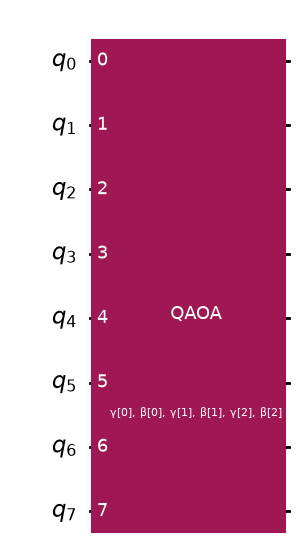

In [4]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
np.random.seed(0)




H = SparsePauliOp.from_sparse_list(
    [
        ("Z", [0], -35),
        ("Z", [1], -52),
        ("Z", [2], -69),
        ("Z", [3], -88),
        ("Z", [4], -16),
        ("Z", [5], -32),
        ("Z", [6], -64),
        ("Z", [7], -16),
    
     
        ("ZZ", [0], 8),
        ("ZZ", [1], 18),
        ("ZZ", [2], 32),
        ("ZZ", [3], 50),
        ("ZZ", [4], 2),
        ("ZZ", [5], 8),
        ("ZZ", [6], 32),
        ("ZZ", [7], 2),

        ("ZZ", [0, 1], 24),
        ("ZZ", [0, 2], 32),
        ("ZZ", [0, 3], 40),
        ("ZZ", [0, 4], 4),
        ("ZZ", [0, 5], 8),
        ("ZZ", [0, 6], 16),
        ("ZZ", [0, 7], 8),
        ("ZZ", [1, 2], 48),
        ("ZZ", [1, 3], 60),
        ("ZZ", [1, 4], 12),
        ("ZZ", [1, 5], 24),
        ("ZZ", [1, 6], 48),
        ("ZZ", [1, 7], 12),
        ("ZZ", [2, 3], 80),
        ("ZZ", [2, 4], 16),
        ("ZZ", [2, 5], 32),
        ("ZZ", [2, 6], 64),
        ("ZZ", [2, 7], 16),
        ("ZZ", [3, 4], 20),
        ("ZZ", [3, 5], 40),
        ("ZZ", [3, 6], 80),
        ("ZZ", [3, 7], 20),
        ("ZZ", [4, 5], 8),
        ("ZZ", [4, 6], 16),
        ("ZZ", [4, 7], 4),
        ("ZZ", [5, 6], 32),
        ("ZZ", [5, 7], 8),
        ("ZZ", [6, 7], 16),
    ],
    num_qubits=8
)



ansatz = QAOAAnsatz(cost_operator=H, reps=3)
x0 = np.random.uniform(0, 2*np.pi, ansatz.num_parameters) 
ansatz.draw(output = "mpl")

In [5]:
estimator = StatevectorEstimator() 
def cost_function(params, ansatz, hamiltonian): 
    pub = (ansatz, [hamiltonian], [params]) 
    result = estimator.run([pub]).result() 
    return result[0].data.evs[0]


result = minimize(cost_function, x0, args=(ansatz, H), method='COBYLA')
print(result)

/Users/buituananh/Downloads/quantum-prep/quantum-env/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/buituananh/Downloads/quantum-prep/quantum-env/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/Users/buituananh/Downloads/quantum-prep/quantum-env/lib/python3.13/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


KeyboardInterrupt: 